# Descomposición de series temporales

La descomposición permite dividir una serie temporal en varios componentes fundamentales:

- Tendencia: Comportamiento de largo plazo (subida o bajada sostenida).
- Estacionalidad: Patrones que se repiten en intervalos fijos (como ciclos anuales).
- Ruido o residuo: Variaciones impredecibles no explicadas por los anteriores.


Estas tres partes pueden sumarse o multiplicarse para formar la serie original. En este curso trabajaremos la descomposición aditiva, donde

## Paso 1. Cargar los datos y visualizar la serie completa.

In [12]:
# cargando todas las librerías necesarias
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
# scales
from sklearn.preprocessing import MinMaxScaler
# labels categoricos
from sklearn.preprocessing import LabelEncoder
# seasonal
from statsmodels.tsa.seasonal import seasonal_decompose

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("Librerias importadas!")

Librerias importadas!


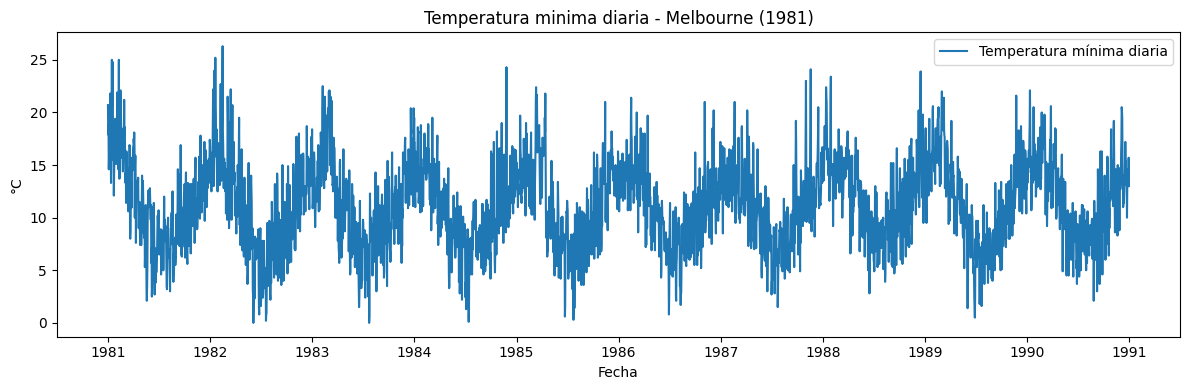

In [13]:


# Cargar datos reales de temperatura minima en Melbourne
url ="https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

# dataset
melbourne = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
melbourne.rename(columns={"Temp": "MinTemp"}, inplace=True)


# Visualización de la serie completa
plt.figure(figsize=(12, 4))
plt.plot(
    melbourne.index,
    melbourne["MinTemp"],
    label="Temperatura mínima diaria")

# titulos
plt.title("Temperatura minima diaria - Melbourne (1981)")
plt.ylabel("°C")
plt.xlabel("Fecha")
plt.legend()
plt.tight_layout()
plt.show()

## Paso 2. Descomposición aditiva asumiendo estacionalidad anual.

In [14]:
# Paso 2: Descomposición aditiva asumiendo estacionalidad anual:
from statsmodels.tsa.seasonal import seasonal_decompose
# Descomposición aditiva asumiendo estacionalidad anual
descomposicion = seasonal_decompose(melbourne["MinTemp"], model="additive", period=365)

## Paso 3. Tendencia

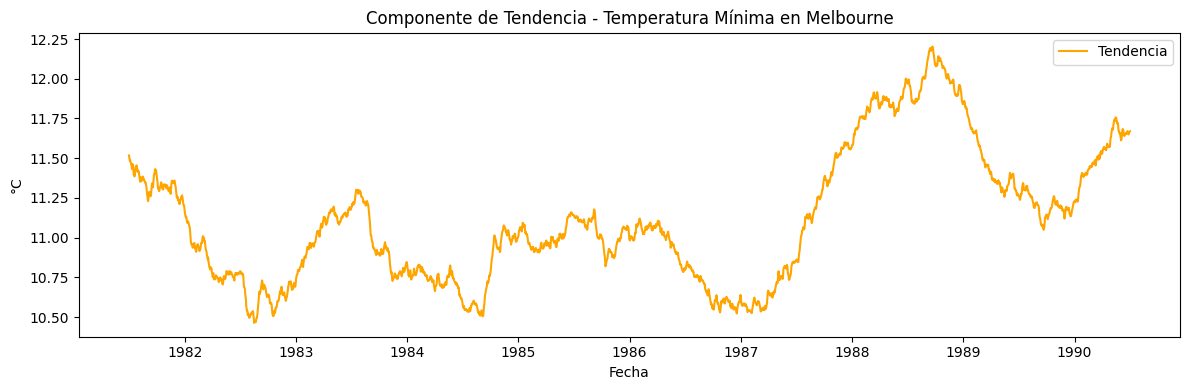

In [15]:
plt.figure(figsize=(12, 4))

# grafico linea
plt.plot(
    descomposicion.trend,
    label="Tendencia",
    color='orange')

# titulos
plt.title("Componente de Tendencia - Temperatura Mínima en Melbourne")
plt.xlabel("Fecha")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()

La tendencia es el patrón de cambio de largo plazo que muestra cómo evoluciona la serie más allá de las variaciones estacionales o aleatorias. En la gráfica 2, observamos lo siguiente:

Descenso inicial (1981–1984): la temperatura mínima diaria promedio muestra una ligera caída. Esto podría interpretarse como un periodo más frío en esos años.
Estabilidad y fluctuaciones (1984–1986): se observan pequeñas subidas y bajadas, pero sin un cambio sostenido.
Aumento pronunciado (1986–1989): hay una tendencia creciente clara. Esto puede estar relacionado con patrones de calentamiento global o condiciones climáticas regionales anómalas.
Nuevo descenso y recuperación (1989–1990): al final del periodo, la tendencia muestra una baja seguida de una ligera recuperación

## Paso 4: Estacionalidad.

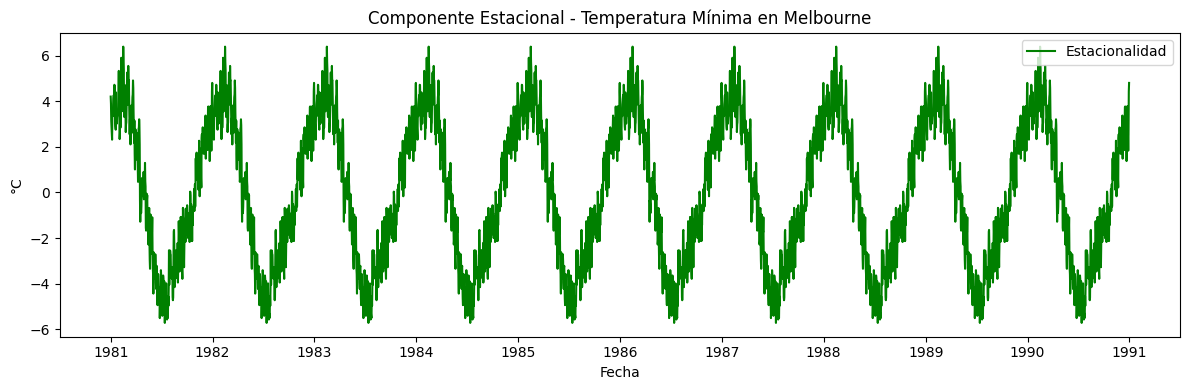

In [16]:
# Paso 4: Estacionalidad:
plt.figure(figsize=(12, 4))

# grafico
plt.plot(
    descomposicion.seasonal,
    label="Estacionalidad",
    color='green')

# titulo
plt.title("Componente Estacional - Temperatura Mínima en Melbourne")
plt.xlabel("Fecha")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()

La estacionalidad representa patrones que se repiten en intervalos de tiempo fijos (por ejemplo, cada año, cada trimestre o cada semana). En el gráfico de estacionalidad para la temperatura mínima diaria en Melbourne observamos:

- Un patrón ondulante muy regular con una frecuencia anual.
- Los picos máximos se repiten aproximadamente en la misma época cada año (verano austral), así como los mínimos (invierno).
- La amplitud estacional es de aproximadamente ±6 °C respecto al promedio.

## Paso 5. Residuo.

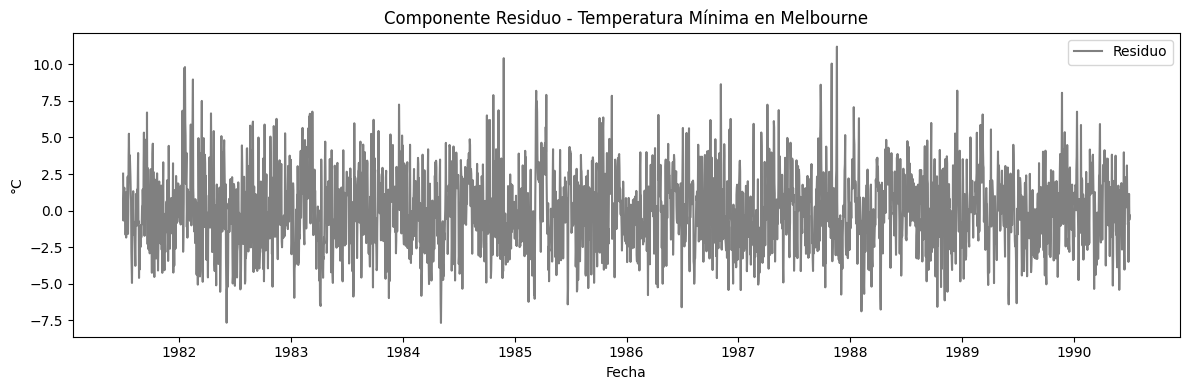

In [17]:
# Paso 4: Residuo:
plt.figure(figsize=(12, 4))

# grafico
plt.plot(
    descomposicion.resid,
    label="Residuo",
    color='gray')

# titulos
plt.title("Componente Residuo - Temperatura Mínima en Melbourne")
plt.xlabel("Fecha")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()

El ruido (también llamado residuo) representa la parte de la serie temporal que no puede explicarse por la tendencia ni la estacionalidad. En otras palabras, son las variaciones impredecibles, aleatorias o causadas por factores externos que no se modelaron.

Observaciones del gráfico:

- El residuo oscila alrededor del 0 con alta frecuencia.
- No sigue un patrón regular, y sus valores pueden variar desde aproximadamente −8 °C hasta +10 °C.
- Picos o caídas abruptas reflejan posibles eventos climáticos extremos, como tormentas, olas de calor o errores en medición.


En el caso de la empresa ClimaPredict, analizar el ruido les ayuda a:

- Detectar eventos anómalos que escapan al patrón normal (útil para generar alertas tempranas).
- Evaluar la calidad del modelo: si el ruido muestra patrones, significa que el modelo aún no captura toda la estructura de la serie.
- Tomar decisiones de negocio considerando el grado de incertidumbre.

**Un buen modelo de series temporales debe minimizar el ruido y dejarlo sin estructura. Si el residuo muestra patrón, ¡aún hay trabajo por hacer!**

# Métodos avanzados de suavizado

## Promedio móvil

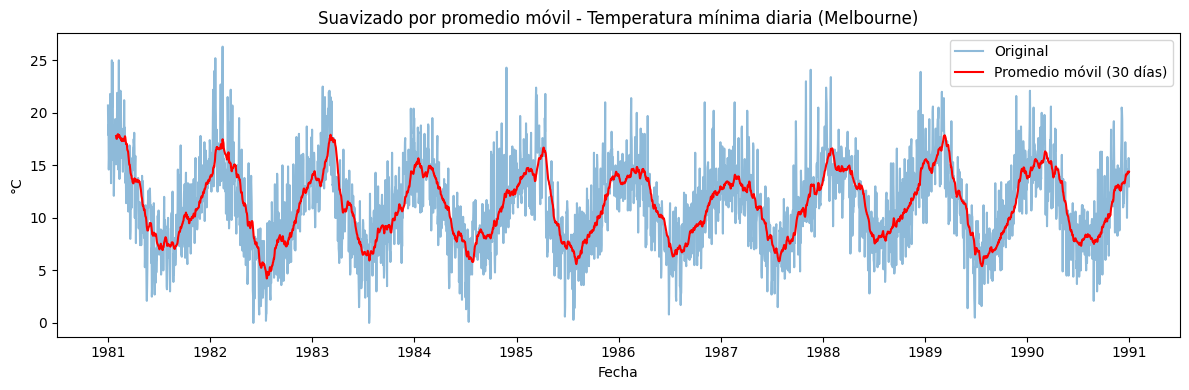

In [18]:
# Suavizado por promedio móvil (ventana de 30 días)
melbourne["MinTemp_MA30"] = melbourne["MinTemp"].rolling(window=30).mean()

# Visualización
plt.figure(figsize=(12, 4))

plt.plot(
    melbourne["MinTemp"],
    label="Original",
    alpha=0.5)


plt.plot(
    melbourne["MinTemp_MA30"],
    label="Promedio móvil (30 días)",
    color="red")


plt.title("Suavizado por promedio móvil - Temperatura mínima diaria (Melbourne)")
plt.ylabel("°C")
plt.xlabel("Fecha")
plt.legend()
plt.tight_layout()
plt.show()

**En el gráfico se comparan dos líneas:**

- Línea azul clara: temperatura mínima diaria original. Esta serie es muy volátil y presenta muchos picos, haciendo difícil detectar patrones a simple vista.
- Línea roja: serie suavizada con promedio móvil de 30 días. Filtra las variaciones diarias y revela con claridad el comportamiento general a lo largo del tiempo.

**Observaciones clave:**

Claridad en la estacionalidad.
- El promedio móvil destaca los ciclos anuales de invierno-verano.
- Las caídas y subidas de temperatura son más suaves, pero siguen una estructura clara: invierno con valores bajos, verano con valores altos.

Reducción del ruido.
- La línea roja elimina las oscilaciones bruscas y permite ver la forma “real” del comportamiento térmico.
- Esto ayuda a evitar decisiones reactivas basadas en variaciones aleatorias.

Ventana de suavizado.
- Se usa 30 días por su lógica mensual. Para ClimaPredict, esto ayuda a analizar temperaturas a escala mensual para ajustar sus modelos o generar informes.

el promedio móvil como una herramienta exploratoria para visualizar tendencias de temperatura sin que el ruido diario nuble el panorama. Esto permite generar reportes ejecutivos más claros, tomar decisiones estratégicas de pronóstico mensual o ajustar sensores con base en tendencias reales y no anomalías.

## suavizado exponencial simple

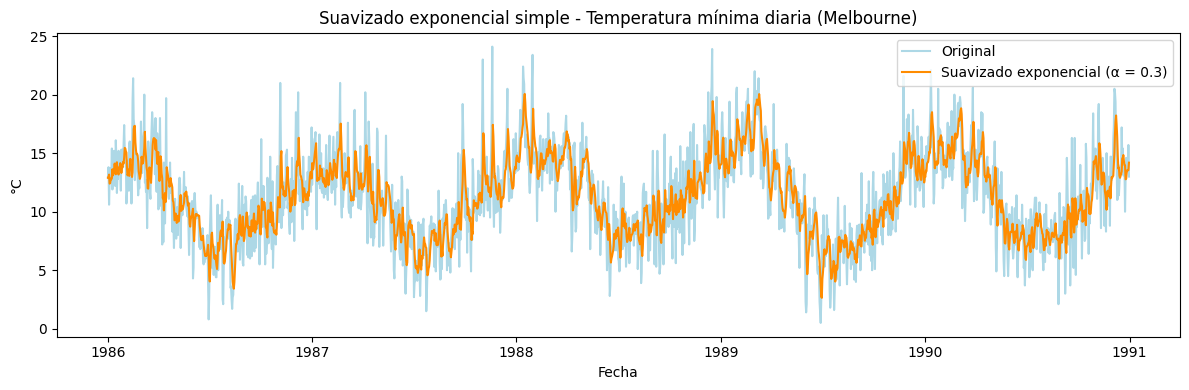

In [25]:
# suavizado exponencial simple

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Tomar un subconjunto de la serie (ej. últimos 5 años) para visualizar mejor
subset = melbourne["MinTemp"].loc["1986":]

# Ajustar modelo de suavizado exponencial simple
model = SimpleExpSmoothing(subset).fit(smoothing_level=0.3, optimized=False)
exp_smooth = model.fittedvalues

# Visualización
plt.figure(figsize=(12, 4))


plt.plot(
    subset.index,
    subset,
    color="lightblue",
    label="Original")

plt.plot(
    subset.index,
    exp_smooth,
    color="darkorange",
    label="Suavizado exponencial (α = 0.3)")

# titulos
plt.title("Suavizado exponencial simple - Temperatura mínima diaria (Melbourne)")
plt.xlabel("Fecha")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()


**Análisis de la salida**

  - Curva original (celeste): muestra alta variabilidad y picos pronunciados. Esto representa los valores reales diarios de temperatura mínima en Melbourne entre 1986 y 1991.
- Curva suavizada (naranja): responde de forma más flexible a los cambios recientes, pero sin seguir las oscilaciones bruscas. Esto ocurre porque:
  - Al usar α=0.3, el modelo da mayor peso a los datos más recientes, pero aún considera el pasado (70% de la información proviene del historial).
  - La serie suavizada se ajusta rápidamente ante cambios sostenidos, pero filtra el ruido o los picos aislados.

**Este suavizado**

- Permite detectar cambios recientes (como un descenso prolongado de temperatura) sin caer en alarmas por variaciones momentáneas.
- Es útil para informes operativos semanales, donde no se necesita un modelo de predicción complejo, pero sí una señal de alerta confiable.
- No capta bien ciclos largos o estacionalidades, por lo que no sustituye a modelos como ARIMA o SARIMA (que veremos más adelante), pero es excelente como paso exploratorio y de limpieza.

### Resumen
- El promedio móvil ayuda a destacar la estacionalidad y la tendencia general, útil para generar reportes mensuales o comunicar hallazgos a tomadores de decisiones no técnicos.
- El suavizado exponencial simple, al responder más rápidamente a los cambios recientes, permite desarrollar alertas tempranas ante desviaciones sostenidas, como un descenso atípico de temperatura.

**filtrar lo importante de lo circunstancial.**

**funcionan mejor como filtros previos o herramientas exploratorias**

# Modelos ARIMA y SARIMA

técnicas estadísticas diseñadas específicamente para modelar y predecir series temporales, considerando tanto su dependencia del pasado como su estructura interna.

## ARIMA

 los modelos ARIMA se utilizan cuando la serie no presenta estacionalidad significativa pero sí dependencias temporales entre observaciones.

“El modelo ARIMA no predice valores absolutos, sino cambios y estructuras internas.”

### Diagnóstico de Estacionariedad.

necesitamos saber si la serie es estacionaria. Esto significa que sus propiedades estadísticas (media, varianza, autocorrelación) no cambian en el tiempo.

La prueba ADF es una prueba estadística que nos ayuda a decidir si una serie es estacionaria:

- H₀ (hipótesis nula): la serie tiene una raíz unitaria → no es estacionaria
- H₁ (alternativa): la serie es estacionaria
- Si el p-valor < 0.05, se rechaza H₀ y se concluye que la serie es estacionaria.

In [26]:
# Prueba de Dickey-Fuller aumentada (ADF)

from statsmodels.tsa.stattools import adfuller

# Prueba de estacionariedad
resultado_adf = adfuller(melbourne["MinTemp"])
print("Estadístico ADF:", resultado_adf[0])
print("Valor p:", resultado_adf[1])

Estadístico ADF: -4.4448049246117
Valor p: 0.0002470826300360994


- Estadístico ADF: -4.44
- Valor p: 0.00025


Como p < 0.05, rechazamos la hipótesis nula de que la serie tiene una raíz unitaria.


**Conclusión:**
la serie de temperaturas mínimas diarias ya es estacionaria (al menos en primera instancia), por lo que no es necesario diferenciarla para aplicar un modelo ARIMA.

### ¿Qué pasa si la serie no es estacionaria?

#### Paso 1. Crear una serie no estacionaria artificial.

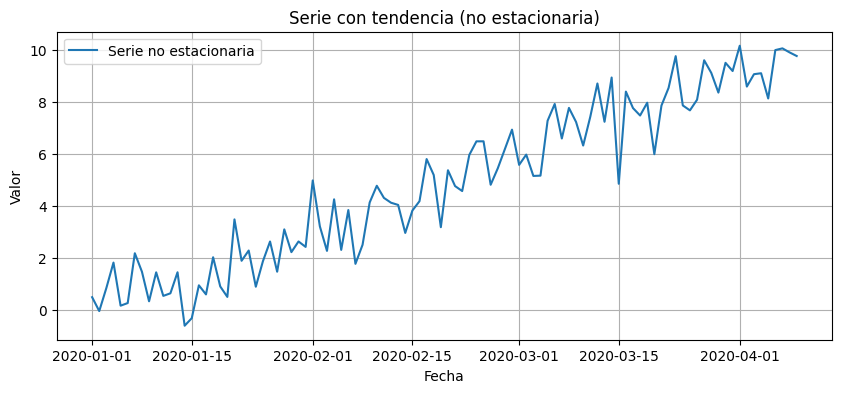

In [27]:
# Paso 1: Crear una serie no estacionaria artificial

# Crear una serie con tendencia (no estacionaria)
np.random.seed(42)
n = 100
tendencia = np.linspace(0, 10, n)
ruido = np.random.normal(0, 1, n)
serie_no_estacionaria = tendencia + ruido

# Convertir en DataFrame
df = pd.DataFrame(serie_no_estacionaria, columns=["valor"])
df["fecha"] = pd.date_range(start="2020-01-01", periods=n)
df.set_index("fecha", inplace=True)

# Visualizar
plt.figure(figsize=(10, 4))
plt.plot(df, label="Serie no estacionaria")
plt.title("Serie con tendencia (no estacionaria)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()


#### Paso 2. Prueba ADF para confirmar que no es estacionaria.

In [28]:
#Paso 2: Prueba ADF para confirmar que no es estacionaria
resultado_adf = adfuller(df["valor"])
print(f"Estadístico ADF: {resultado_adf[0]}")
print(f"Valor p: {resultado_adf[1]}")

Estadístico ADF: -0.14542254502389032
Valor p: 0.9447220932126499


p > 0.05, lo que indica que no podemos rechazar la hipótesis nula de que la serie tiene raíz unitaria (es decir, no es estacionaria).

#### Paso 3. Diferenciar la serie (una vez).

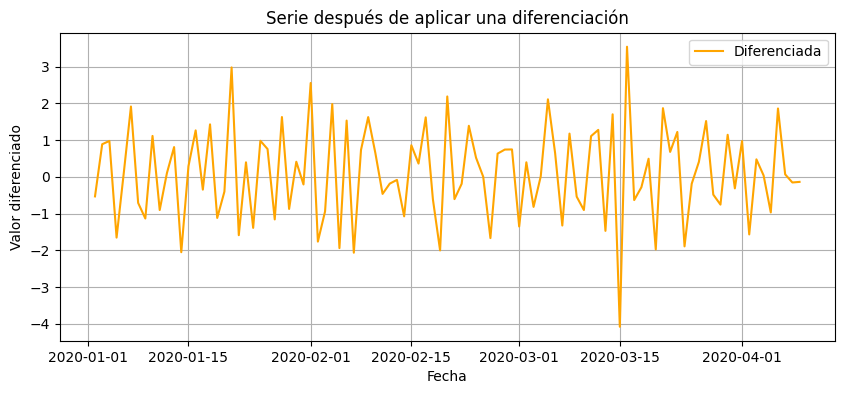

In [29]:
# Paso 3: Diferenciar la serie (una vez)

df["diferenciada"] = df["valor"].diff()

# Visualizar
plt.figure(figsize=(10, 4))
plt.plot(df["diferenciada"], color="orange", label="Diferenciada")
plt.title("Serie después de aplicar una diferenciación")
plt.xlabel("Fecha")
plt.ylabel("Valor diferenciado")
plt.legend()
plt.grid(True)
plt.show()


#### Paso 4. Volver a aplicar el test ADF.

In [30]:
# Paso 4: Volver a aplicar el test ADF
resultado_adf_dif = adfuller(df["diferenciada"].dropna())
print(f"Estadístico ADF (diferenciada): {resultado_adf_dif[0]}")
print(f"Valor p (diferenciada): {resultado_adf_dif[1]}")


Estadístico ADF (diferenciada): -5.19456786307988
Valor p (diferenciada): 9.019393985742036e-06


Interpretación:

p < 0.05, lo que indica que ahora sí podemos rechazar la hipótesis nula, ¡la serie ya es estacionaria!

#### CONSTRUCCIÓN DEL MODELO ARIMA

<Figure size 1000x400 with 0 Axes>

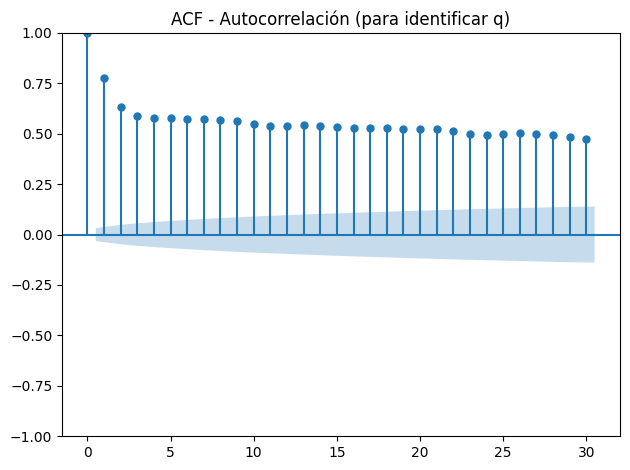

In [44]:
# Paso 1: Identificación de los parámeros p y q
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF: autocorrelación para identificar q
plt.figure(figsize=(10, 4))
plot_acf(melbourne["MinTemp"], lags=30)
plt.title("ACF - Autocorrelación (para identificar q)")
plt.tight_layout()
plt.show()


**¿Cómo interpretar la ACF en modelos ARIMA?**

La Función de Autocorrelación (ACF) mide la relación entre los valores actuales de una serie temporal y sus rezagos pasados (lags). Es una herramienta clave para identificar el componente de media móvil (MA) en un modelo ARIMA, es decir, el parámetro q.

¿Qué buscar en el gráfico de ACF?

- Corte abrupto en los primeros rezagos → sugiere la presencia de un componente MA fuerte.
- Disminución gradual sin corte claro → indica que la parte MA (q) es débil o poco dominante, y podría estar presente un componente AR (autoregresivo).

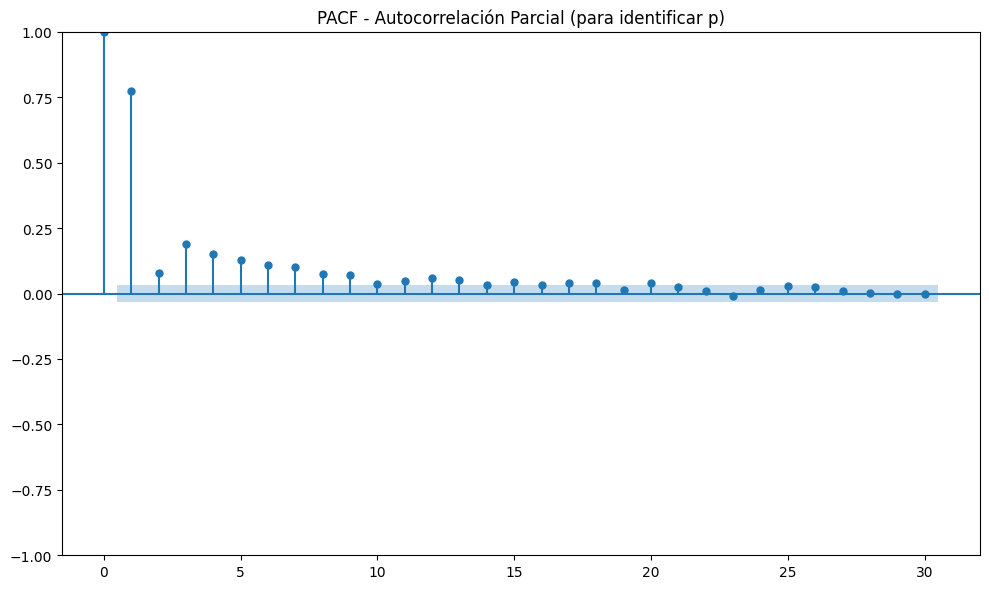

In [43]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import arma_generate_sample

# PACF: autocorrelación parcial para identificar p
fig, ax = plt.subplots(figsize=(10, 6))


plot_pacf(melbourne["MinTemp"], lags=30, ax=ax)
plt.title("PACF - Autocorrelación Parcial (para identificar p)")
plt.tight_layout()
plt.show()


La Función de Autocorrelación Parcial (PACF) permite evaluar la relación entre un valor actual de la serie temporal y sus valores pasados, eliminando la influencia de los rezagos intermedios. Se utiliza para identificar el componente autoregresivo (AR), es decir, el parámetro p en el modelo ARIMA.

**¿Qué observar en la PACF?**

- Corte claro después de cierto rezago → sugiere que p debe ser igual a ese número de rezagos.
- Disminución gradual sin corte definido → puede indicar una estructura más compleja o necesidad de más rezagos A

En el análisis de la temperatura mínima diaria en Melbourne, observamos que:

- El rezago 1 muestra una autocorrelación parcial muy alta (~0.8).
- A partir del rezago 2, los valores caen rápidamente y se mantienen cerca de cero dentro del intervalo de confianza.

Conclusión inicial: podríamos comenzar probando el modelo ARIMA con p = 1, lo que indica un fuerte componente autoregresivo de primer orden.


<Figure size 1000x400 with 0 Axes>

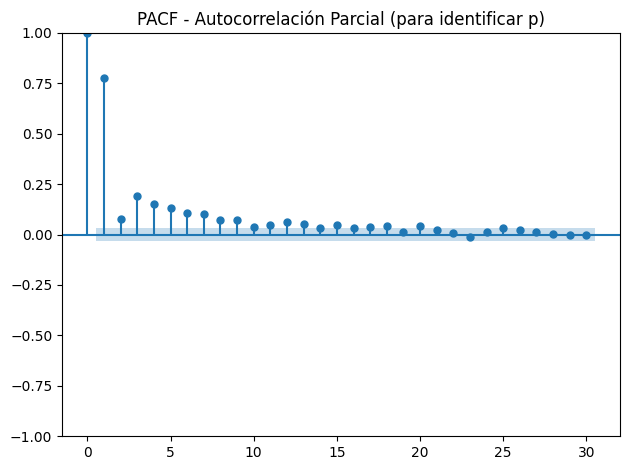

In [45]:
# PACF: autocorrelación parcial para identificar p
plt.figure(figsize=(10, 4))
plot_pacf(melbourne["MinTemp"], lags=30)
plt.title("PACF - Autocorrelación Parcial (para identificar p)")
plt.tight_layout()
plt.show()


#### Ajuste del modelo ARIMA(1,0,1)

                               SARIMAX Results                                
Dep. Variable:                MinTemp   No. Observations:                 3650
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -8605.425
Date:                Sat, 04 Oct 2025   AIC                          17218.851
Time:                        22:51:19   BIC                          17243.661
Sample:                             0   HQIC                         17227.686
                               - 3650                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1965      0.240     46.721      0.000      10.727      11.666
ar.L1          0.8649      0.011     81.948      0.000       0.844       0.886
ma.L1         -0.2414      0.019    -12.604      0.0

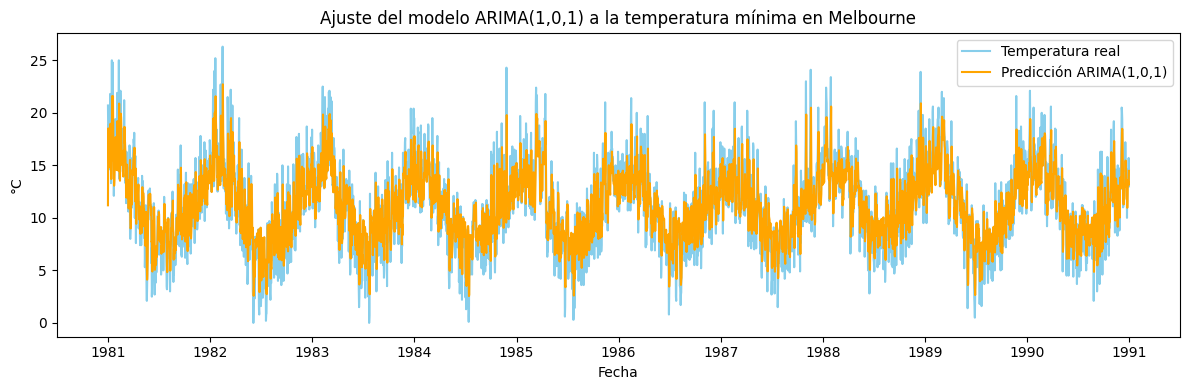

In [46]:
#Ajuste del modelo ARIMA(1,0,1)

from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Ajustar modelo ARIMA(1,0,1)
modelo_arima = ARIMA(melbourne["MinTemp"], order=(1, 0, 1))
resultado_arima = modelo_arima.fit()

# Mostrar resumen del modelo
print(resultado_arima.summary())

# Generar predicciones in-sample (ajuste al mismo conjunto de datos)
predicciones = resultado_arima.fittedvalues

# Visualización
plt.figure(figsize=(12, 4))
plt.plot(melbourne.index, melbourne["MinTemp"], label="Temperatura real", color='skyblue')
plt.plot(melbourne.index, predicciones, label="Predicción ARIMA(1,0,1)", color='orange')
plt.title("Ajuste del modelo ARIMA(1,0,1) a la temperatura mínima en Melbourne")
plt.xlabel("Fecha")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()


Confirmación del modelo

Tu modelo fue:

ARIMA(1, 0, 1) → es decir:
- p = 1 → un componente autoregresivo (AR)
- d = 0 → no se aplicó diferenciación (la serie ya era estacionaria)
- q = 1 → un componente de media móvil (MA)

- const	11.1965	Media de la serie (temperatura promedio estimada)
- ar.L1	0.8649	La temperatura de hoy depende fuertemente de la de ayer (alta autocorrelación)
- ma.L1	-0.2414	Ajuste fino de errores previos para corregir la predicción
- sigma2	6.5349	Varianza del error (más bajo es mejor)

**Todos los coeficientes son estadísticamente significativos (p < 0.05) → el modelo es robusto**

Métricas de desempeño:

- Log-Likelihood = -8605.425: Cuanto más alto, mejor (se usa internamente para cálculos de AIC/BIC).
- AIC = 17218.851 / BIC = 17243.661: Útiles para comparar modelos. El más bajo indica mejor ajuste con penalización por complejidad.

## SARIMA

SARIMA es ideal para series que muestran estacionalidad clara y estructurada, como la temperatura mínima diaria de Melbourne, que se repite cada 365 días.

El modelo SARIMA (Seasonal AutoRegressive Integrated Moving Average) es una extensión de ARIMA que incorpora componentes estacionales. Mientras que ARIMA modela patrones no estacionales como tendencia y ruido, SARIMA también puede capturar patrones que se repiten cíclicamente, como estaciones del año, meses o semanas.

SARIMA se usa cuando la serie presenta estacionalidad evidente, es decir, patrones que se repiten cada cierto intervalo de tiempo fijo. En nuestro caso, la serie de temperaturas mínimas en Melbourne tiene una clara estacionalidad anual, por lo tanto, un modelo SARIMA es más adecuado.

## Paso 1: Definir y ajustar el modelo SARIMA

In [47]:
# Aplicar SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Reducir a últimos 3 años
melbourne_reducido = melbourne["1987":]

# Ajustar modelo SARIMA
modelo_sarima = SARIMAX(melbourne_reducido["MinTemp"],
                        order=(1,0,1),
                        seasonal_order=(1,1,1,12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

resultado_sarima = modelo_sarima.fit(method="powell", disp=False)

# Imprimir resumen
print(resultado_sarima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                            MinTemp   No. Observations:                 1460
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood               -3344.760
Date:                            Sat, 04 Oct 2025   AIC                           6699.519
Time:                                    23:08:36   BIC                           6725.861
Sample:                                         0   HQIC                          6709.355
                                           - 1460                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8375      0.019     45.105      0.000       0.801       0.874
ma.L1         -0.1626      0.031   

- ar.L1 = 0.8375	Componente autoregresivo (AR) a rezago 1. La temperatura actual depende fuertemente de la anterior.
- ma.L1 = -0.1626	Componente de media móvil (MA) que corrige el error del día anterior.
- ar.S.L12 ≈ 0	El efecto autoregresivo estacional no es significativo (p > 0.05).
- ma.S.L12 = -1.029	El componente MA estacional es muy fuerte: corrige errores de 12 meses atrás (patrón anual).
- sigma2 = 5.75	Varianza del error del modelo. Baja, lo que indica que el modelo ajusta bien.

**Métricas del modelo**

- Log-Likelihood = -3344.76 → indicador interno del modelo, cuanto mayor (menos negativo), mejor.
- AIC = 6699.51 / BIC = 6725.86 → usados para comparar modelos, mientras más bajos, mejor el balance entre ajuste y complejidad.
- Ljung-Box test (Q=1.09, p=0.30) → indica que los residuos no presentan autocorrelación significativa, lo cual es deseable.
- Jarque-Bera test (p=0.49) → sugiere que los residuos son aproximadamente normales.
- Heterocedasticidad (p=0.83) → no se detectan cambios grandes de varianza en el tiempo (lo cual también es positivo).

Conclusión

Este modelo muestra un buen ajuste general. En especial:

- Captura muy bien la estacionalidad (componente MA estacional muy fuerte).
- Es estable y estadísticamente válido (residuos normales y no autocorrelacionados).
- Ideal para realizar pronósticos de corto o mediano plazo con fines operativos en ClimaPredict, como alertas y planificación mensual.


Ahora que hemos construido modelos ARIMA y SARIMA ajustados a la serie temporal de ClimaPredict, el siguiente paso lógico es evaluar su desempeño.


# Validación y evaluación de modelos

La validación de modelos de series temporales implica comparar las predicciones realizadas por el modelo con datos reales que el modelo no ha visto. A diferencia de otros tipos de datos, no podemos hacer una partición aleatoria (train/test), ya que el orden cronológico es crucial. En su lugar, se utilizan métodos como:

- Train/Test basado en fechas: Se entrena con los primeros años (por ejemplo, 1981–1988) y se prueba con el último año (1989).
- Validación por ventana móvil (rolling forecast): Se entrena con una ventana que se desplaza en el tiempo y se prueba punto a punto.

## Paso 1. Preparar los datos.

In [49]:
# Paso 1. Preparar los datos

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Definir train y test
train = melbourne.loc[:'1988-12-31']
test = melbourne.loc['1989-01-01':]

# Confirmamos longitud
print(f"Entrenamiento: {len(train)} registros")
print(f"Prueba: {len(test)} registros")


Entrenamiento: 2920 registros
Prueba: 730 registros


## Paso 2: Ajustar y predecir con ARIMA

In [50]:
# Paso 2. Ajustar y predecir con ARIMA

# Ajustar modelo ARIMA
modelo_arima = ARIMA(train['MinTemp'], order=(1, 0, 1))
ajuste_arima = modelo_arima.fit()

# Hacer predicciones para el mismo rango de prueba
pred_arima = ajuste_arima.forecast(steps=len(test))

# Evaluar
rmse_arima = np.sqrt(mean_squared_error(test['MinTemp'], pred_arima))
mae_arima = mean_absolute_error(test['MinTemp'], pred_arima)


## Paso 3. Ajustar y predecir con SARIMA

In [51]:
# Paso 3. Ajustar y predecir con SARIMA

# Ajustar modelo SARIMA con estacionalidad anual (s=12 mensual forzada)
modelo_sarima = SARIMAX(train['MinTemp'],
                        order=(1, 0, 1),
                        seasonal_order=(1, 1, 1, 12))
ajuste_sarima = modelo_sarima.fit()

# Hacer predicciones
pred_sarima = ajuste_sarima.forecast(steps=len(test))

# Evaluar
rmse_sarima = np.sqrt(mean_squared_error(test['MinTemp'], pred_sarima))
mae_sarima = mean_absolute_error(test['MinTemp'], pred_sarima)


## Paso 4. Visualización comparativa.

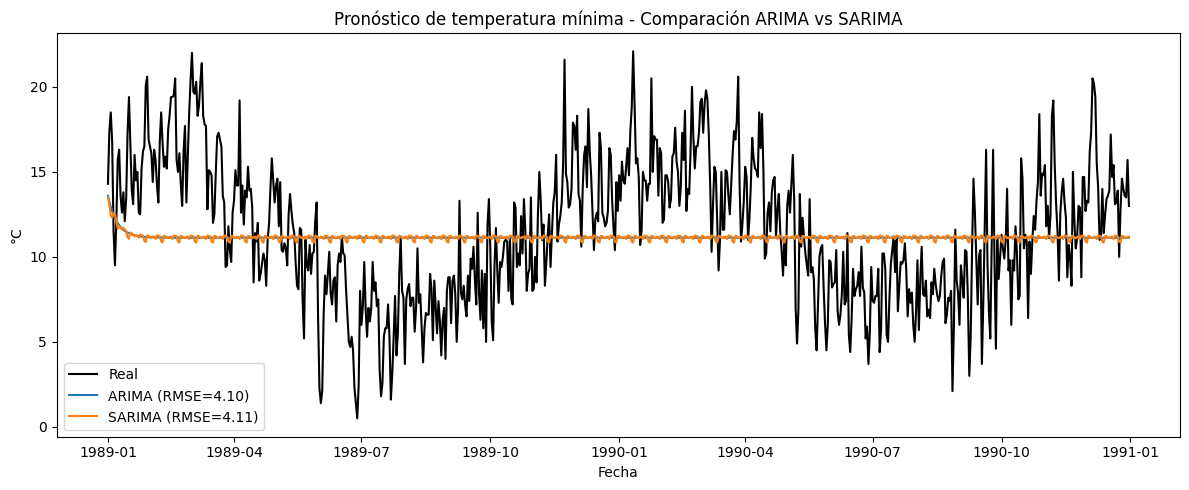

In [52]:
# Paso 4: Visualización comparativa

plt.figure(figsize=(12, 5))
plt.plot(test.index, test["MinTemp"], label="Real", color="black")
plt.plot(test.index, pred_arima, label=f"ARIMA (RMSE={rmse_arima:.2f})")
plt.plot(test.index, pred_sarima, label=f"SARIMA (RMSE={rmse_sarima:.2f})")
plt.title("Pronóstico de temperatura mínima - Comparación ARIMA vs SARIMA")
plt.xlabel("Fecha")
plt.ylabel("°C")
plt.legend()
plt.tight_layout()
plt.show()


# Comparación de las predicciones hechas por los modelos:

## Paso 1. Usa solo una porción de los datos.

In [53]:
# Generar predicciones

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Usamos solo una porción para test para facilitar visualización
train = melbourne["MinTemp"].iloc[:-365]
test = melbourne["MinTemp"].iloc[-365:]


## Paso 2. Ajuste de ambos modelos.

In [54]:
# 1. Ajustamos ambos modelos
# ARIMA(1, 0, 1)
arima_model = ARIMA(train, order=(1, 0, 1)).fit()

# SARIMA(1, 0, 1)(1, 1, 1, 12)
sarima_model = SARIMAX(train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 12)).fit()


## Paso 3. Hacer pronóstico sobre los próximos 5 días.

In [55]:
# 2. Hacemos pronóstico sobre los próximos 5 días
# Pronóstico
forecast_days = 5
arima_forecast = arima_model.forecast(steps=forecast_days)
sarima_forecast = sarima_model.forecast(steps=forecast_days)
real_values = test.iloc[:forecast_days]


## Paso 4. Crea una tabla comparativa.

In [56]:
# 3. Creamos una tabla comparativa

# Construir DataFrame comparativo
comparison_df = pd.DataFrame({
    "Fecha": real_values.index,
    "Real (°C)": real_values.values,
    "ARIMA (°C)": arima_forecast.values,
    "SARIMA (°C)": sarima_forecast.values
})

print(comparison_df)



       Fecha  Real (°C)  ARIMA (°C)  SARIMA (°C)
0 1990-01-01       14.8   12.593034    12.510410
1 1990-01-02       13.3   12.400973    12.223219
2 1990-01-03       15.6   12.234355    12.113987
3 1990-01-04       14.5   12.089811    12.001828
4 1990-01-05       14.3   11.964415    11.940840
